In [44]:
# ============================================================
# BLOCK 1: IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [45]:
# ============================================================
# BLOCK 2: CREATE STUDENT DATASET
# ============================================================

np.random.seed(42)

n_students = 500

student_id = [
    f"S{str(i).zfill(3)}"
    for i in range(1, n_students + 1)
]

# Generate student-related features
study_hours = np.random.uniform(1, 10, n_students)

attendance = np.random.uniform(50, 100, n_students)

previous_marks = np.random.uniform(40, 95, n_students)

assignment_score = np.random.uniform(40, 100, n_students)

internal_marks = np.random.uniform(40, 95, n_students)

# Generate final marks based on the features
final_marks = (
    0.25 * (study_hours * 10)
    + 0.20 * attendance
    + 0.25 * previous_marks
    + 0.10 * assignment_score
    + 0.20 * internal_marks
)

# Add some random variation
noise = np.random.normal(0, 4, n_students)

final_marks = final_marks + noise

# Keep marks within 0-100
final_marks = np.clip(final_marks, 0, 100)

# Create DataFrame
df = pd.DataFrame({
    "Student_ID": student_id,
    "Study_Hours": study_hours.round(2),
    "Attendance": attendance.round(2),
    "Previous_Marks": previous_marks.round(2),
    "Assignment_Score": assignment_score.round(2),
    "Internal_Marks": internal_marks.round(2),
    "Final_Marks": final_marks.round(2)
})

print("Dataset created successfully!")
print("Number of students:", len(df))

Dataset created successfully!
Number of students: 500


In [46]:
# ============================================================
# BLOCK 3: DISPLAY DATASET
# ============================================================

print("First 10 records:")
display(df.head(10))

First 10 records:


,Student_ID,Study_Hours,Attendance,Previous_Marks,Assignment_Score,Internal_Marks,Final_Marks
0,S001,4.37,84.91,50.18,71.14,54.39,60.53
1,S002,9.56,76.80,69.80,68.75,53.58,76.88
2,S003,7.59,65.48,88.01,41.54,89.84,78.41
3,S004,6.39,90.69,80.27,60.47,53.73,71.33
4,S005,2.40,84.24,84.36,62.81,54.96,60.43
5,S006,2.40,58.13,76.23,63.93,81.77,58.84
6,S007,1.52,95.55,78.08,74.81,64.74,62.08
7,S008,8.80,91.13,86.71,72.02,82.72,90.17
8,S009,6.41,97.49,53.73,76.47,43.60,67.70
9,S010,7.37,86.29,66.92,85.89,66.82,62.61


In [47]:
# ============================================================
# BLOCK 4: DATASET INFORMATION
# ============================================================

print("Dataset Shape:")
print(df.shape)

print("\nDataset Information:")
df.info()

Dataset Shape:
(500, 7)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Student_ID        500 non-null    object 
 1   Study_Hours       500 non-null    float64
 2   Attendance        500 non-null    float64
 3   Previous_Marks    500 non-null    float64
 4   Assignment_Score  500 non-null    float64
 5   Internal_Marks    500 non-null    float64
 6   Final_Marks       500 non-null    float64
dtypes: float64(6), object(1)
memory usage: 27.5+ KB


In [48]:
# ============================================================
# BLOCK 4: DATASET INFORMATION
# ============================================================

print("Dataset Shape:")
print(df.shape)

print("\nDataset Information:")
df.info()

Dataset Shape:
(500, 7)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Student_ID        500 non-null    object 
 1   Study_Hours       500 non-null    float64
 2   Attendance        500 non-null    float64
 3   Previous_Marks    500 non-null    float64
 4   Assignment_Score  500 non-null    float64
 5   Internal_Marks    500 non-null    float64
 6   Final_Marks       500 non-null    float64
dtypes: float64(6), object(1)
memory usage: 27.5+ KB


In [49]:
# ============================================================
# BLOCK 6: CHECK MISSING VALUES
# ============================================================

print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Student_ID          0
Study_Hours         0
Attendance          0
Previous_Marks      0
Assignment_Score    0
Internal_Marks      0
Final_Marks         0
dtype: int64


In [50]:
# ============================================================
# BLOCK 7: SAVE DATASET
# ============================================================

df.to_csv("student_performance.csv", index=False)

print("Dataset saved as student_performance.csv")

Dataset saved as student_performance.csv


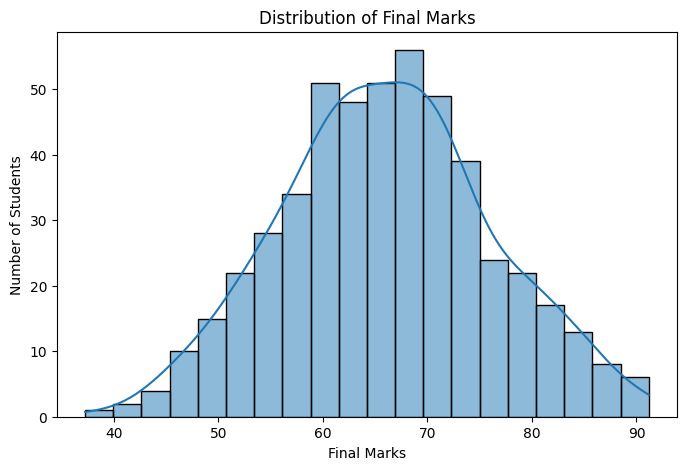

In [51]:
# ============================================================
# BLOCK 8: FINAL MARKS DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    df["Final_Marks"],
    bins=20,
    kde=True
)

plt.title("Distribution of Final Marks")
plt.xlabel("Final Marks")
plt.ylabel("Number of Students")

plt.show()

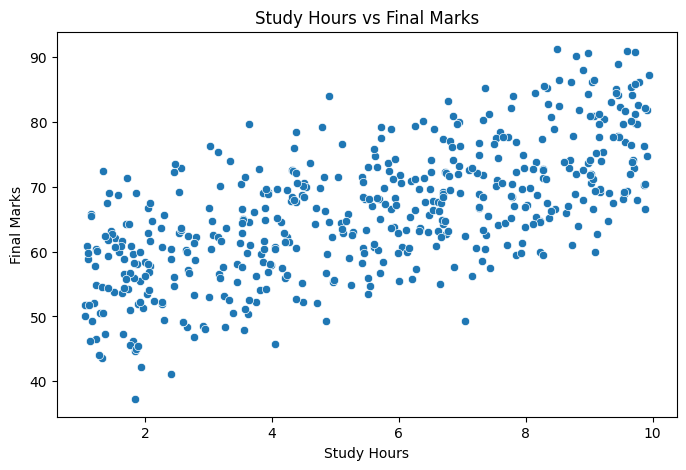

In [52]:
# ============================================================
# BLOCK 9: STUDY HOURS VS FINAL MARKS
# ============================================================

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Study_Hours",
    y="Final_Marks"
)

plt.title("Study Hours vs Final Marks")
plt.xlabel("Study Hours")
plt.ylabel("Final Marks")

plt.show()

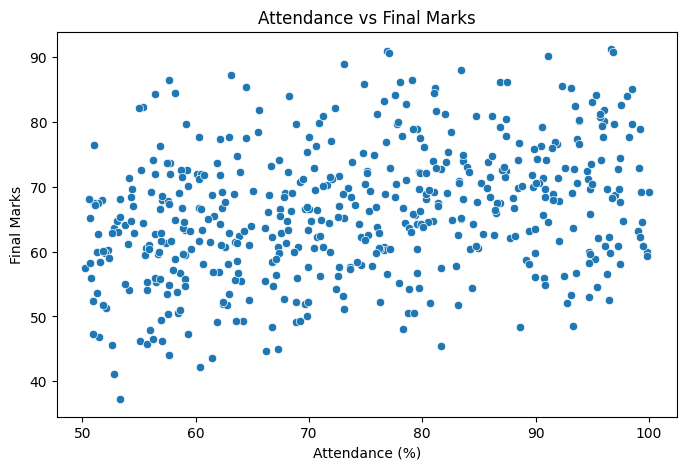

In [53]:
# ============================================================
# BLOCK 10: ATTENDANCE VS FINAL MARKS
# ============================================================

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Attendance",
    y="Final_Marks"
)

plt.title("Attendance vs Final Marks")
plt.xlabel("Attendance (%)")
plt.ylabel("Final Marks")

plt.show()

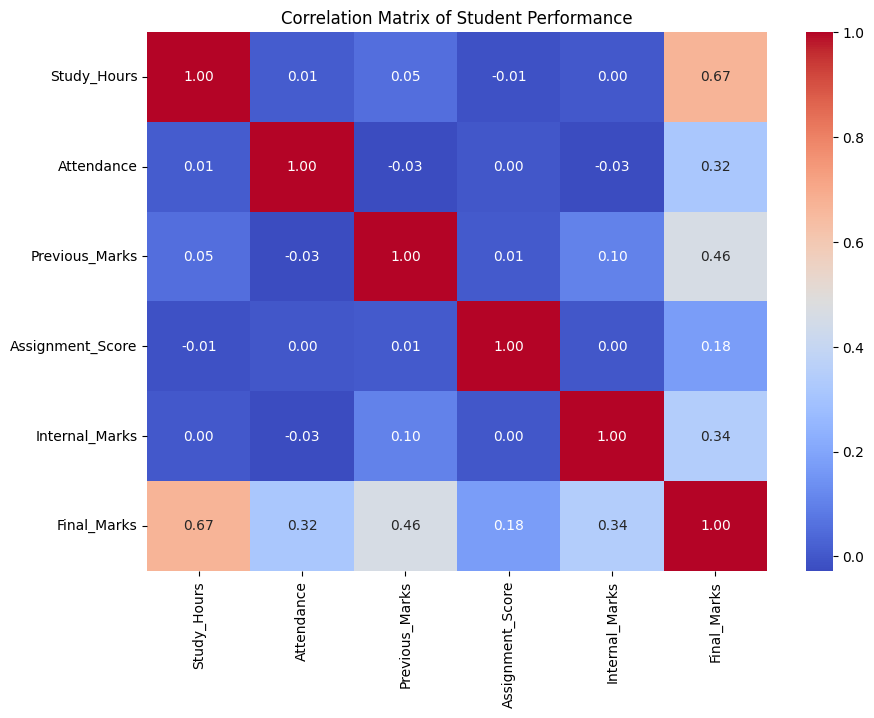

In [54]:
# ============================================================
# BLOCK 11: CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(10, 7))

correlation = df.select_dtypes(
    include=np.number
).corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Student Performance")

plt.show()

In [55]:
# ============================================================
# BLOCK 12: PREPARE DATA FOR LINEAR REGRESSION
# ============================================================

features = [
    "Study_Hours",
    "Attendance",
    "Previous_Marks",
    "Assignment_Score",
    "Internal_Marks"
]

X = df[features]

y = df["Final_Marks"]

print("Input features:")
print(features)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Input features:
['Study_Hours', 'Attendance', 'Previous_Marks', 'Assignment_Score', 'Internal_Marks']

X shape: (500, 5)
y shape: (500,)


In [56]:
# ============================================================
# BLOCK 13: TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 400
Testing samples : 100


In [57]:
# ============================================================
# BLOCK 14: LINEAR REGRESSION MODEL
# ============================================================

linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [58]:
# ============================================================
# BLOCK 15: REGRESSION COEFFICIENTS
# ============================================================

coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": linear_model.coef_
})

display(coefficients)

print("Intercept:", linear_model.intercept_)

,Feature,Coefficient
0,Study_Hours,2.361904
1,Attendance,0.233279
2,Previous_Marks,0.253266
3,Assignment_Score,0.102581
4,Internal_Marks,0.203264


Intercept: -2.211885157718484


In [59]:
# ============================================================
# BLOCK 16: PREDICT FINAL MARKS
# ============================================================

y_pred = linear_model.predict(X_test)

print("First 10 predictions:")

for actual, predicted in zip(
    y_test.values[:10],
    y_pred[:10]
):
    print(
        f"Actual: {actual:.2f}  |  "
        f"Predicted: {predicted:.2f}"
    )

First 10 predictions:
Actual: 71.68  |  Predicted: 64.83
Actual: 85.19  |  Predicted: 74.14
Actual: 53.56  |  Predicted: 51.46
Actual: 55.85  |  Predicted: 59.75
Actual: 69.19  |  Predicted: 78.04
Actual: 65.13  |  Predicted: 67.29
Actual: 57.78  |  Predicted: 61.48
Actual: 64.67  |  Predicted: 67.44
Actual: 58.88  |  Predicted: 56.93
Actual: 63.84  |  Predicted: 68.18


In [60]:
# ============================================================
# BLOCK 17: EVALUATE LINEAR REGRESSION
# ============================================================

mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)

print("Linear Regression Performance")
print("--------------------------------")
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

Linear Regression Performance
--------------------------------
MAE  : 2.93
MSE  : 14.16
RMSE : 3.76
R²   : 0.8397


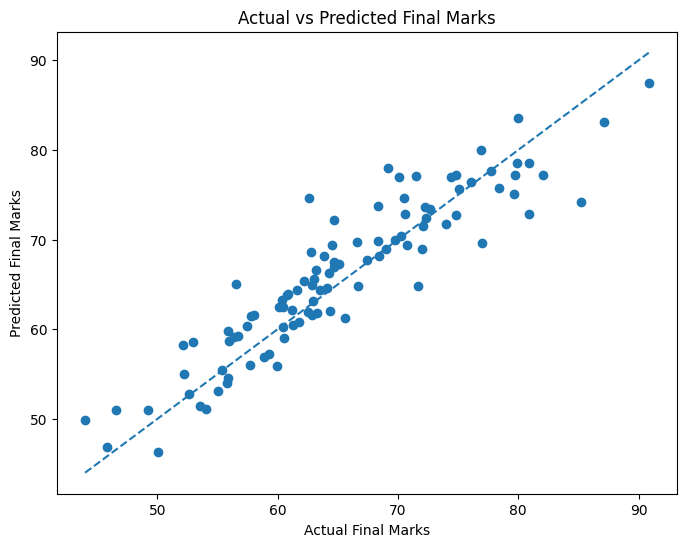

In [61]:
# ============================================================
# BLOCK 18: ACTUAL VS PREDICTED MARKS
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Final Marks")
plt.ylabel("Predicted Final Marks")

plt.title("Actual vs Predicted Final Marks")

# Reference line
minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.show()

In [62]:
# ============================================================
# BLOCK 19: NEW STUDENT PREDICTION FUNCTION
# ============================================================

def predict_student_performance(
    study_hours,
    attendance,
    previous_marks,
    assignment_score,
    internal_marks
):

    new_student = pd.DataFrame({
        "Study_Hours": [study_hours],
        "Attendance": [attendance],
        "Previous_Marks": [previous_marks],
        "Assignment_Score": [assignment_score],
        "Internal_Marks": [internal_marks]
    })

    prediction = linear_model.predict(new_student)

    return prediction[0]

In [63]:
# ============================================================
# BLOCK 20: TEST NEW STUDENT
# ============================================================

predicted_marks = predict_student_performance(
    study_hours=7,
    attendance=88,
    previous_marks=76,
    assignment_score=82,
    internal_marks=79
)

print("New Student")
print("--------------------------------")
print("Study Hours      :", 7)
print("Attendance       :", 88)
print("Previous Marks   :", 76)
print("Assignment Score :", 82)
print("Internal Marks   :", 79)

print("--------------------------------")
print(
    f"Predicted Final Marks: {predicted_marks:.2f}"
)

New Student
--------------------------------
Study Hours      : 7
Attendance       : 88
Previous Marks   : 76
Assignment Score : 82
Internal Marks   : 79
--------------------------------
Predicted Final Marks: 78.57


In [64]:
# ============================================================
# BLOCK 21: PREPARE DATA FOR K-MEANS
# ============================================================

cluster_features = [
    "Study_Hours",
    "Attendance",
    "Previous_Marks",
    "Assignment_Score",
    "Internal_Marks"
]

cluster_data = df[cluster_features]

print("Features used for clustering:")
print(cluster_features)

display(cluster_data.head())


Features used for clustering:
['Study_Hours', 'Attendance', 'Previous_Marks', 'Assignment_Score', 'Internal_Marks']


,Study_Hours,Attendance,Previous_Marks,Assignment_Score,Internal_Marks
0,4.37,84.91,50.18,71.14,54.39
1,9.56,76.80,69.80,68.75,53.58
2,7.59,65.48,88.01,41.54,89.84
3,6.39,90.69,80.27,60.47,53.73
4,2.40,84.24,84.36,62.81,54.96


In [65]:
# ============================================================
# BLOCK 22: STANDARDIZE CLUSTERING DATA
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    cluster_data
)

print("Data standardized successfully!")
print("Scaled data shape:", X_scaled.shape)

Data standardized successfully!
Scaled data shape: (500, 5)


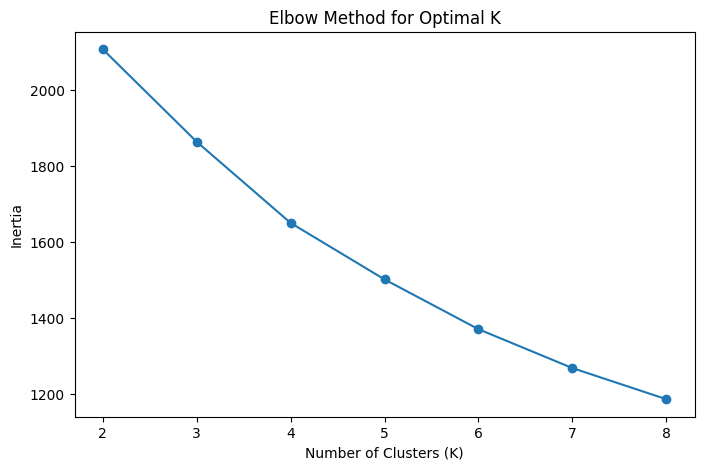

In [66]:
# ============================================================
# BLOCK 23: ELBOW METHOD
# ============================================================

inertia = []

K_values = range(2, 9)

for k in K_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(
    K_values,
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.title("Elbow Method for Optimal K")

plt.xticks(K_values)

plt.show()

In [67]:
# ============================================================
# BLOCK 24: K-MEANS CLUSTERING
# ============================================================

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(
    X_scaled
)

df["Cluster"] = cluster_labels

print("K-Means clustering completed!")

K-Means clustering completed!


In [68]:
# ============================================================
# BLOCK 25: DISPLAY CLUSTER RESULTS
# ============================================================

display(
    df[
        [
            "Student_ID",
            "Study_Hours",
            "Attendance",
            "Previous_Marks",
            "Assignment_Score",
            "Internal_Marks",
            "Final_Marks",
            "Cluster"
        ]
    ].head(20)
)

,Student_ID,Study_Hours,Attendance,Previous_Marks,Assignment_Score,Internal_Marks,Final_Marks,Cluster
0,S001,4.37,84.91,50.18,71.14,54.39,60.53,0
1,S002,9.56,76.80,69.80,68.75,53.58,76.88,0
2,S003,7.59,65.48,88.01,41.54,89.84,78.41,1
3,S004,6.39,90.69,80.27,60.47,53.73,71.33,0
4,S005,2.40,84.24,84.36,62.81,54.96,60.43,2
5,S006,2.40,58.13,76.23,63.93,81.77,58.84,2
6,S007,1.52,95.55,78.08,74.81,64.74,62.08,2
7,S008,8.80,91.13,86.71,72.02,82.72,90.17,1
8,S009,6.41,97.49,53.73,76.47,43.60,67.70,0
9,S010,7.37,86.29,66.92,85.89,66.82,62.61,0


In [69]:
# ============================================================
# BLOCK 26: CLUSTER SIZE
# ============================================================

cluster_counts = df["Cluster"].value_counts().sort_index()

print("Number of students in each cluster:")
print(cluster_counts)

Number of students in each cluster:
Cluster
0    159
1    159
2    182
Name: count, dtype: int64


In [70]:
# ============================================================
# BLOCK 27: CLUSTER CHARACTERISTICS
# ============================================================

cluster_summary = df.groupby("Cluster")[
    [
        "Study_Hours",
        "Attendance",
        "Previous_Marks",
        "Assignment_Score",
        "Internal_Marks",
        "Final_Marks"
    ]
].mean()

display(
    cluster_summary.round(2)
)

,Study_Hours,Attendance,Previous_Marks,Assignment_Score,Internal_Marks,Final_Marks
Cluster,,,,,,
0,7.05,78.26,64.68,70.08,53.04,67.17
1,7.23,71.93,71.25,66.90,81.63,72.73
2,2.60,72.35,69.34,72.05,67.76,59.36


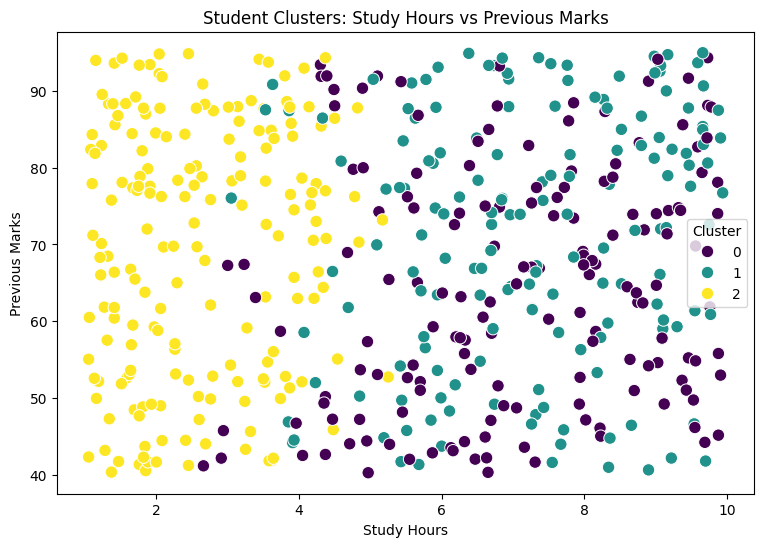

In [71]:
# ============================================================
# BLOCK 28: STUDY HOURS VS PREVIOUS MARKS
# ============================================================

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Study_Hours",
    y="Previous_Marks",
    hue="Cluster",
    palette="viridis",
    s=80
)

plt.title(
    "Student Clusters: Study Hours vs Previous Marks"
)

plt.xlabel("Study Hours")
plt.ylabel("Previous Marks")

plt.legend(title="Cluster")

plt.show()

In [72]:
# ============================================================
# BLOCK 29: PCA FOR CLUSTER VISUALIZATION
# ============================================================

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

df["PCA1"] = X_pca[:, 0]
df["PCA2"] = X_pca[:, 1]

print(
    "Explained variance ratio:",
    pca.explained_variance_ratio_
)

Explained variance ratio: [0.22534721 0.20418716]


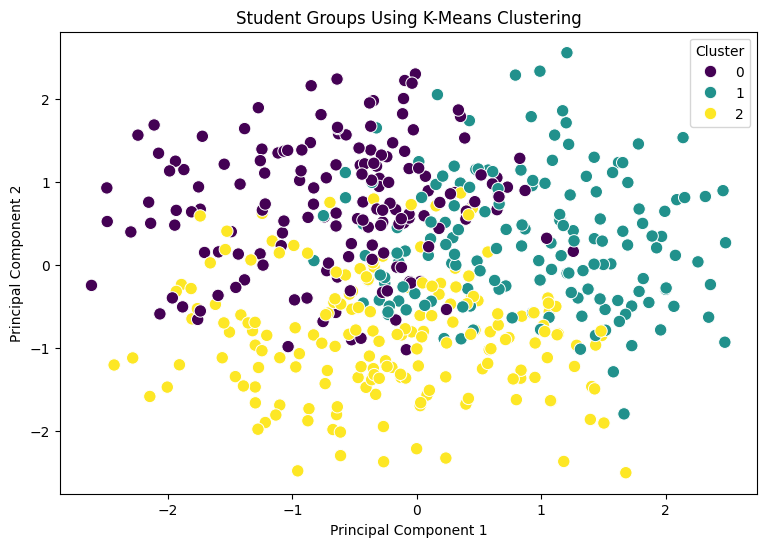

In [73]:
# ============================================================
# BLOCK 30: PCA CLUSTER VISUALIZATION
# ============================================================

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="viridis",
    s=80
)

plt.title("Student Groups Using K-Means Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(title="Cluster")

plt.show()

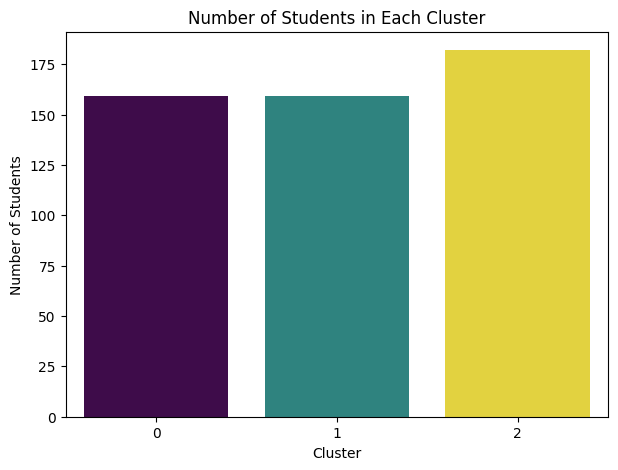

In [74]:
# ============================================================
# BLOCK 31: CLUSTER DISTRIBUTION
# ============================================================

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Cluster",
    hue="Cluster",
    palette="viridis",
    legend=False
)

plt.title("Number of Students in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Students")

plt.show()

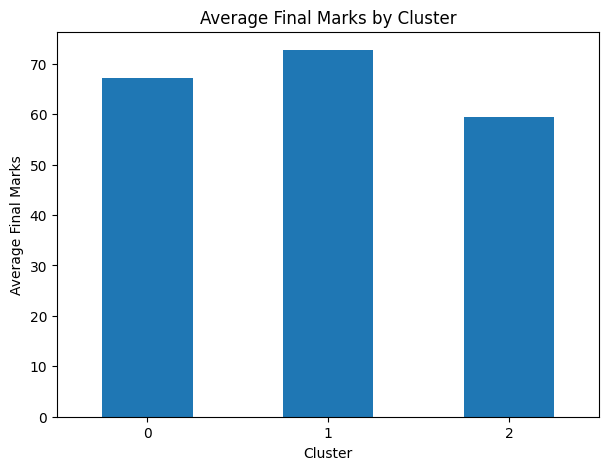

In [75]:
# ============================================================
# BLOCK 32: AVERAGE FINAL MARKS BY CLUSTER
# ============================================================

cluster_final_marks = df.groupby(
    "Cluster"
)["Final_Marks"].mean()

plt.figure(figsize=(7, 5))

cluster_final_marks.plot(
    kind="bar"
)

plt.xlabel("Cluster")
plt.ylabel("Average Final Marks")

plt.title("Average Final Marks by Cluster")

plt.xticks(rotation=0)

plt.show()

In [76]:
# ============================================================
# BLOCK 33: COMPLETE CLUSTER ANALYSIS
# ============================================================

final_cluster_summary = df.groupby("Cluster").agg({
    "Student_ID": "count",
    "Study_Hours": "mean",
    "Attendance": "mean",
    "Previous_Marks": "mean",
    "Assignment_Score": "mean",
    "Internal_Marks": "mean",
    "Final_Marks": "mean"
})

final_cluster_summary = final_cluster_summary.rename(
    columns={
        "Student_ID": "Number_of_Students"
    }
)

display(
    final_cluster_summary.round(2)
)

,Number_of_Students,Study_Hours,Attendance,Previous_Marks,Assignment_Score,Internal_Marks,Final_Marks
Cluster,,,,,,,
0,159,7.05,78.26,64.68,70.08,53.04,67.17
1,159,7.23,71.93,71.25,66.90,81.63,72.73
2,182,2.60,72.35,69.34,72.05,67.76,59.36


In [77]:
# ============================================================
# BLOCK 34: COMPLETE NEW STUDENT ANALYSIS
# ============================================================

def analyze_new_student(
    study_hours,
    attendance,
    previous_marks,
    assignment_score,
    internal_marks
):

    # Create new student dataframe
    new_student = pd.DataFrame({
        "Study_Hours": [study_hours],
        "Attendance": [attendance],
        "Previous_Marks": [previous_marks],
        "Assignment_Score": [assignment_score],
        "Internal_Marks": [internal_marks]
    })

    # -----------------------------
    # Linear Regression Prediction
    # -----------------------------

    predicted_marks = linear_model.predict(
        new_student
    )[0]

    # -----------------------------
    # K-Means Cluster Prediction
    # -----------------------------

    new_student_scaled = scaler.transform(
        new_student[cluster_features]
    )

    predicted_cluster = kmeans.predict(
        new_student_scaled
    )[0]

    return predicted_marks, predicted_cluster

In [78]:
# ============================================================
# BLOCK 35: TEST COMPLETE SYSTEM
# ============================================================

marks, cluster = analyze_new_student(
    study_hours=7,
    attendance=88,
    previous_marks=76,
    assignment_score=82,
    internal_marks=79
)

print("=" * 50)
print("       STUDENT PERFORMANCE ANALYSIS")
print("=" * 50)

print(f"Study Hours       : {7}")
print(f"Attendance        : {88}%")
print(f"Previous Marks    : {76}")
print(f"Assignment Score  : {82}")
print(f"Internal Marks    : {79}")

print("-" * 50)

print(f"Predicted Final Marks : {marks:.2f}")
print(f"Student Cluster       : Cluster {cluster}")

print("=" * 50)

       STUDENT PERFORMANCE ANALYSIS
Study Hours       : 7
Attendance        : 88%
Previous Marks    : 76
Assignment Score  : 82
Internal Marks    : 79
--------------------------------------------------
Predicted Final Marks : 78.57
Student Cluster       : Cluster 1


In [79]:
# ============================================================
# BLOCK 36: SAVE FINAL DATASET WITH CLUSTERS
# ============================================================

df.to_csv(
    "student_performance_with_clusters.csv",
    index=False
)

print(
    "Final dataset saved as "
    "student_performance_with_clusters.csv"
)

Final dataset saved as student_performance_with_clusters.csv


In [ ]:
# ============================================================
# BLOCK 37: DOWNLOAD DATASET
# ============================================================

#from google.colab import files


ModuleNotFoundError: No module named 'google.colab'